In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# Load enhanced dataset
df = pd.read_csv('../data/processed/daily_features.csv', index_col=0, parse_dates=True)
df = df.asfreq('D')

# Define intervention date
intervention_date = pd.Timestamp('2011-04-01')

# Pre-intervention data (for training and validation)
pre = df[df.index < intervention_date].copy()

print(f"Pre-intervention period: {pre.index.min()} to {pre.index.max()}")
print(f"Total pre-intervention days: {len(pre)}")

Pre-intervention period: 2010-12-01 00:00:00 to 2011-03-31 00:00:00
Total pre-intervention days: 121


In [3]:
# Use last 60 days for validation (adjust if pre period is short)
validation_days = 60
train = pre.iloc[:-validation_days]
valid = pre.iloc[-validation_days:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Validation: {valid.index.min()} to {valid.index.max()} ({len(valid)} days)")

Train: 2010-12-01 00:00:00 to 2011-01-30 00:00:00 (61 days)
Validation: 2011-01-31 00:00:00 to 2011-03-31 00:00:00 (60 days)


In [4]:
# Seasonal naive: use revenue from 7 days ago
y_true = valid['revenue']
y_pred_naive = train['revenue'].iloc[-7:].values  # last week's pattern
# Repeat pattern to cover validation period
y_pred_naive = np.tile(y_pred_naive, int(np.ceil(len(valid)/7)))[:len(valid)]

mae_naive = mean_absolute_error(y_true, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_true, y_pred_naive))
mape_naive = mean_absolute_percentage_error(y_true, y_pred_naive)

print(f"Seasonal Naive - MAE: {mae_naive:.0f}, RMSE: {rmse_naive:.0f}, MAPE: {mape_naive:.2%}")

Seasonal Naive - MAE: 4264, RMSE: 6014, MAPE: 22.01%


In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit on training data
ets_model = ExponentialSmoothing(train['revenue'], 
                                 trend='add', 
                                 seasonal='add', 
                                 seasonal_periods=7)
ets_fit = ets_model.fit()
ets_forecast = ets_fit.forecast(len(valid))

# Evaluate
mae_ets = mean_absolute_error(valid['revenue'], ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(valid['revenue'], ets_forecast))
mape_ets = mean_absolute_percentage_error(valid['revenue'], ets_forecast)

print(f"ETS - MAE: {mae_ets:.0f}, RMSE: {rmse_ets:.0f}, MAPE: {mape_ets:.2%}")

ETS - MAE: 12873, RMSE: 15332, MAPE: 740272929998788100096.00%


In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit on training data
ets_model = ExponentialSmoothing(train['revenue'], 
                                 trend='add', 
                                 seasonal='add', 
                                 seasonal_periods=7)
ets_fit = ets_model.fit()
ets_forecast = ets_fit.forecast(len(valid))

# Evaluate
mae_ets = mean_absolute_error(valid['revenue'], ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(valid['revenue'], ets_forecast))
mape_ets = mean_absolute_percentage_error(valid['revenue'], ets_forecast)

print(f"ETS - MAE: {mae_ets:.0f}, RMSE: {rmse_ets:.0f}, MAPE: {mape_ets:.2%}")

ETS - MAE: 12873, RMSE: 15332, MAPE: 740272929998788100096.00%


In [10]:
from prophet import Prophet

# Create Prophet dataframes correctly
train_prophet = train.reset_index().rename(columns={train.index.name: 'ds', 'revenue': 'y'})
valid_prophet = valid.reset_index().rename(columns={valid.index.name: 'ds', 'revenue': 'y'})

# Ensure 'ds' is datetime and no timezone
train_prophet['ds'] = pd.to_datetime(train_prophet['ds']).dt.tz_localize(None)
valid_prophet['ds'] = pd.to_datetime(valid_prophet['ds']).dt.tz_localize(None)

# Build model
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
prophet_model.add_country_holidays(country_name='UK')
prophet_model.fit(train_prophet)

# Predict
future = prophet_model.make_future_dataframe(periods=len(valid), include_history=False)
forecast = prophet_model.predict(future)
prophet_forecast = forecast['yhat'].values

# Evaluate
mae_prophet = mean_absolute_error(valid['revenue'], prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(valid['revenue'], prophet_forecast))
mape_prophet = mean_absolute_percentage_error(valid['revenue'], prophet_forecast)

print(f"Prophet - MAE: {mae_prophet:.0f}, RMSE: {rmse_prophet:.0f}, MAPE: {mape_prophet:.2%}")

20:32:04 - cmdstanpy - INFO - Chain [1] start processing
20:32:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 10080, RMSE: 11796, MAPE: 630590973377932558336.00%


In [12]:
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

# Feature columns (excluding target and date)
feature_cols = ['dayofweek', 'month', 'weekofyear', 'is_holiday',
                'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 
                'rolling_mean_7']

# Drop rows with NaN from lags (first few rows)
train_lgb = train.dropna().copy()
valid_lgb = valid.dropna().copy()

X_train = train_lgb[feature_cols]
y_train = train_lgb['revenue']
X_valid = valid_lgb[feature_cols]
y_valid = valid_lgb['revenue']

# LightGBM model
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, 
                              max_depth=5, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_forecast = lgb_model.predict(X_valid)

# Evaluate
mae_lgb = mean_absolute_error(y_valid, lgb_forecast)
rmse_lgb = np.sqrt(mean_squared_error(y_valid, lgb_forecast))
mape_lgb = mean_absolute_percentage_error(y_valid, lgb_forecast)

print(f"LightGBM - MAE: {mae_lgb:.0f}, RMSE: {rmse_lgb:.0f}, MAPE: {mape_lgb:.2%}")

LightGBM - MAE: 9412, RMSE: 11541, MAPE: 1046172171568516956160.00%


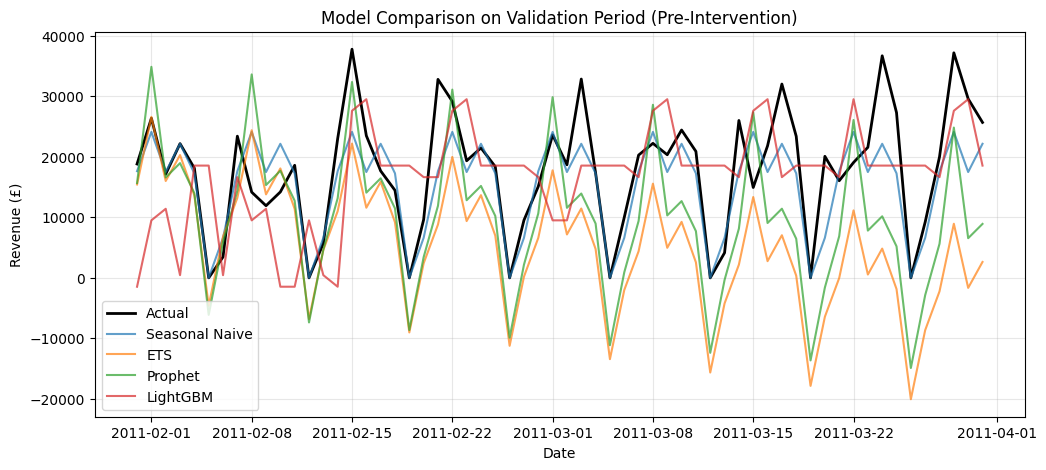

In [13]:
plt.figure(figsize=(12,5))
plt.plot(valid.index, valid['revenue'], label='Actual', linewidth=2, color='black')
plt.plot(valid.index, y_pred_naive[:len(valid)], label='Seasonal Naive', alpha=0.7)
plt.plot(valid.index, ets_forecast, label='ETS', alpha=0.7)
plt.plot(valid.index, prophet_forecast, label='Prophet', alpha=0.7)
plt.plot(valid.index, lgb_forecast, label='LightGBM', alpha=0.7)
plt.title('Model Comparison on Validation Period (Pre-Intervention)')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
results = pd.DataFrame({
    'Model': ['Seasonal Naive', 'ETS', 'Prophet', 'LightGBM'],
    'MAE': [mae_naive, mae_ets, mae_prophet, mae_lgb],
    'RMSE': [rmse_naive, rmse_ets, rmse_prophet, rmse_lgb],
    'MAPE': [mape_naive, mape_ets, mape_prophet, mape_lgb]
})

results = results.sort_values('MAPE')
print(results)

            Model           MAE          RMSE          MAPE
0  Seasonal Naive   4264.151833   6014.074846  2.200704e-01
2         Prophet  10080.318447  11796.340045  6.305910e+18
1             ETS  12873.097486  15332.250447  7.402729e+18
3        LightGBM   9412.383361  11540.945507  1.046172e+19


In [15]:
best_model_name = results.iloc[0]['Model']
print(f"Best model for counterfactual: {best_model_name}")

# We'll retrain this model on ALL pre-intervention data in Phase 4

Best model for counterfactual: Seasonal Naive


In [16]:
# Full pre-intervention data
full_pre = pre.dropna().copy()  # drop rows with NaN lags if using LightGBM

if best_model_name == 'Prophet':
    train_full_prophet = full_pre.reset_index()[['index', 'revenue']].rename(columns={'index': 'ds', 'revenue': 'y'})
    final_model = Prophet(weekly_seasonality=True, yearly_seasonality=False)
    final_model.fit(train_full_prophet)
    # We'll use this in Phase 4

elif best_model_name == 'LightGBM':
    X_full = full_pre[feature_cols]
    y_full = full_pre['revenue']
    final_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
    final_model.fit(X_full, y_full)

elif best_model_name == 'ETS':
    final_model = ExponentialSmoothing(full_pre['revenue'], trend='add', seasonal='add', seasonal_periods=7)
    final_model = final_model.fit()

else:  # Seasonal Naive (unlikely winner)
    final_model = None  # will handle separately

In [18]:
import joblib
joblib.dump(final_model, f'../models/{best_model_name}_model.pkl')
print(f"Model saved to ../models/{best_model_name}_model.pkl")

Model saved to ../models/Seasonal Naive_model.pkl


In [19]:
# Create a DataFrame with actual vs predictions from the best model on validation set
validation_comparison = pd.DataFrame({
    'date': valid.index,
    'actual': valid['revenue']
})

if best_model_name == 'Prophet':
    validation_comparison['predicted'] = prophet_forecast
elif best_model_name == 'LightGBM':
    validation_comparison['predicted'] = lgb_forecast
elif best_model_name == 'ETS':
    validation_comparison['predicted'] = ets_forecast

validation_comparison.to_csv('../data/processed/validation_predictions.csv', index=False)
print("Validation predictions saved.")

Validation predictions saved.
